In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('dataset_masuk_sd.csv')

# 2. Data Understanding (Melihat info dasar data)
print("=== INFORMASI DATASET ===")
print(df.info())
print("\n=== 5 DATA PERTAMA ===")
print(df.head())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_siswa         15 non-null     int64  
 1   jarak_meter      15 non-null     int64  
 2   umur_tahun       15 non-null     float64
 3   nilai_kesiapan   15 non-null     int64  
 4   status_diterima  15 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 732.0 bytes
None

=== 5 DATA PERTAMA ===
   id_siswa  jarak_meter  umur_tahun  nilai_kesiapan  status_diterima
0         1          450         7.2              85                1
1         2         2300         6.0              70                0
2         3         1200         6.8              90                1
3         4         3500         5.8              65                0
4         5          800         6.5              75                1


In [2]:
from sklearn.model_selection import train_test_split

# 1. Cek Missing Values (Data Kosong)
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

# 2. Pisahkan Fitur (X) dan Target (y)
# Kita drop kolom 'id_siswa' karena tidak berpengaruh pada prediksi
X = df[['jarak_meter', 'umur_tahun', 'nilai_kesiapan']]
y = df['status_diterima']

# 3. Bagi data menjadi Train set (80%) dan Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nJumlah Data Training: {len(X_train)}")
print(f"Jumlah Data Testing: {len(X_test)}")

Jumlah data kosong per kolom:
id_siswa           0
jarak_meter        0
umur_tahun         0
nilai_kesiapan     0
status_diterima    0
dtype: int64

Jumlah Data Training: 12
Jumlah Data Testing: 3


In [3]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inisialisasi Model Random Forest (Poin Plus!)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Training Model dengan data Train
model.fit(X_train, y_train)

print("Model Machine Learning Berhasil Dilatih!")

Model Machine Learning Berhasil Dilatih!


In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Prediksi data test
y_pred = model.predict(X_test)

# 2. Hitung Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Lu: {akurasi * 100:.2f}%\n")

# 3. Cetak Laporan Klasifikasi Lengkap
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

Akurasi Model Lu: 66.67%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.67      0.80         3

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


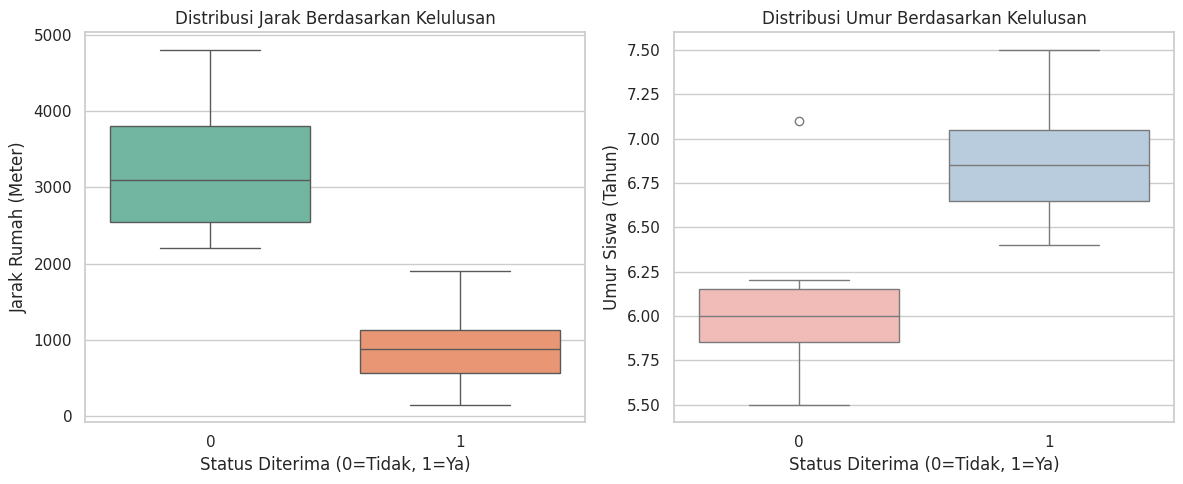

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 2. Grafik Korelasi Jarak vs Status Penerimaan (Sudah diperbaiki dengan hue dan legend=False)
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='status_diterima', y='jarak_meter', hue='status_diterima', palette='Set2', legend=False)
plt.title('Distribusi Jarak Berdasarkan Kelulusan')
plt.xlabel('Status Diterima (0=Tidak, 1=Ya)')
plt.ylabel('Jarak Rumah (Meter)')

# 3. Grafik Korelasi Umur vs Status Penerimaan (Sudah diperbaiki dengan hue dan legend=False)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='status_diterima', y='umur_tahun', hue='status_diterima', palette='Pastel1', legend=False)
plt.title('Distribusi Umur Berdasarkan Kelulusan')
plt.xlabel('Status Diterima (0=Tidak, 1=Ya)')
plt.ylabel('Umur Siswa (Tahun)')

plt.tight_layout()
plt.show()